In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.lines import Line2D
from astropy.table import Table, vstack,hstack
import numpy.ma as ma
import pyneb as pn

import sys
sys.path.insert(1, '/Users/nityaravi/Documents/Github/RotationCurves/ellipticals')
from elliptical_plottingFunctions import *
from IO_data import *
from elliptical_stellar_mass import calc_mass_curve
from elliptical_stellar_mass_functions import exponential_disk, exponential_sphere, exponential_sphere_disk

In [2]:
master_table_fn = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_BPT_v5.fits'

master_table = Table.read(master_table_fn)
master_table[:5]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,logHI,logHIlim,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,Mstar_HI_R90,Mstar_HI_3p5R90,nsa_elpetro_log_mass,Mstar_Mtot_R90,MstarHI_Mtot_R90,nsa_Mstar_Mtot,rabsmag,param_H2_R90,logHe,Mvis_R90,Mvis_Mtot_R90,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err,Mvir2,Mvir2_err,star_sigma2,star_sigma2_err,e_Mstar_R90,BPT_class,sum_M_star_0p1_R90
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,fl

In [3]:
master_table_dict = {}
for i in range(len(master_table)):
    master_table_dict[master_table['plateifu'][i]] = i

In [4]:
PIPE3D_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Pipe3D/'
DATA_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/'
VEL_FOLDER = DATA_FOLDER + 'DR17/'


matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['savefig.dpi'] = 300

In [5]:
plot_dir = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Ellipticals_Images/results_plots/refit_spirals/'

In [6]:
#test gal
gal_ID = '8319-1902'

## BPT diagram classification

1. extract maps for H\alpha H\beta [NII] and [OIII] lines
2. make S/N 3 cut
3. correct fluxes with Balmer decrement
4. plot on BPT diagram and classify spaxels as HII, comp, or AGN

### extract maps

In [10]:
[plate, IFU] = gal_ID.split('-')
fn = VEL_FOLDER + '/' + plate + '/' + IFU + '/manga-' + gal_ID + '-MAPS-HYB10-MILESHC-MASTARSSP.fits.gz'

cube = fits.open(fn)

maps = {}

#Ha
maps['Ha_flux'] = cube['EMLINE_GFLUX'].data[23]
maps['Ha_flux_ivar'] = cube['EMLINE_GFLUX_IVAR'].data[23]
maps['Ha_flux_mask'] = cube['EMLINE_GFLUX_MASK'].data[23]

#Hb
maps['Hb_flux'] = cube['EMLINE_GFLUX'].data[14]
maps['Hb_flux_ivar'] = cube['EMLINE_GFLUX_IVAR'].data[14]
maps['Hb_flux_mask'] = cube['EMLINE_GFLUX_MASK'].data[14]

#[NII]
maps['N2_flux'] = cube['EMLINE_GFLUX'].data[24]
maps['N2_flux_ivar'] = cube['EMLINE_GFLUX_IVAR'].data[24]
maps['N2_flux_mask'] = cube['EMLINE_GFLUX_MASK'].data[24]

#[OIII]
maps['O3_flux'] = cube['EMLINE_GFLUX'].data[16]
maps['O3_flux_ivar'] = cube['EMLINE_GFLUX_IVAR'].data[16]
maps['O3_flux_mask'] = cube['EMLINE_GFLUX_MASK'].data[16]

### apply default mask and sn 3 mask and plot

In [14]:
mHa_flux = ma.array(maps['Ha_flux'], mask = np.logical_or(maps['Ha_flux']*np.sqrt(maps['Ha_flux_ivar']) <3, maps['Ha_flux_mask']))
mHb_flux = ma.array(maps['Hb_flux'], mask = np.logical_or(maps['Hb_flux']*np.sqrt(maps['Hb_flux_ivar']) <3, maps['Hb_flux_mask']))
mN2_flux = ma.array(maps['N2_flux'], mask = np.logical_or(maps['N2_flux']*np.sqrt(maps['N2_flux_ivar']) <3, maps['N2_flux_mask']))
mO3_flux = ma.array(maps['O3_flux'], mask = np.logical_or(maps['O3_flux']*np.sqrt(maps['O3_flux_ivar']) <3, maps['O3_flux_mask']))

Text(0.5, 1.0, '[OIII] flux, S/N $\\geq$ 3')

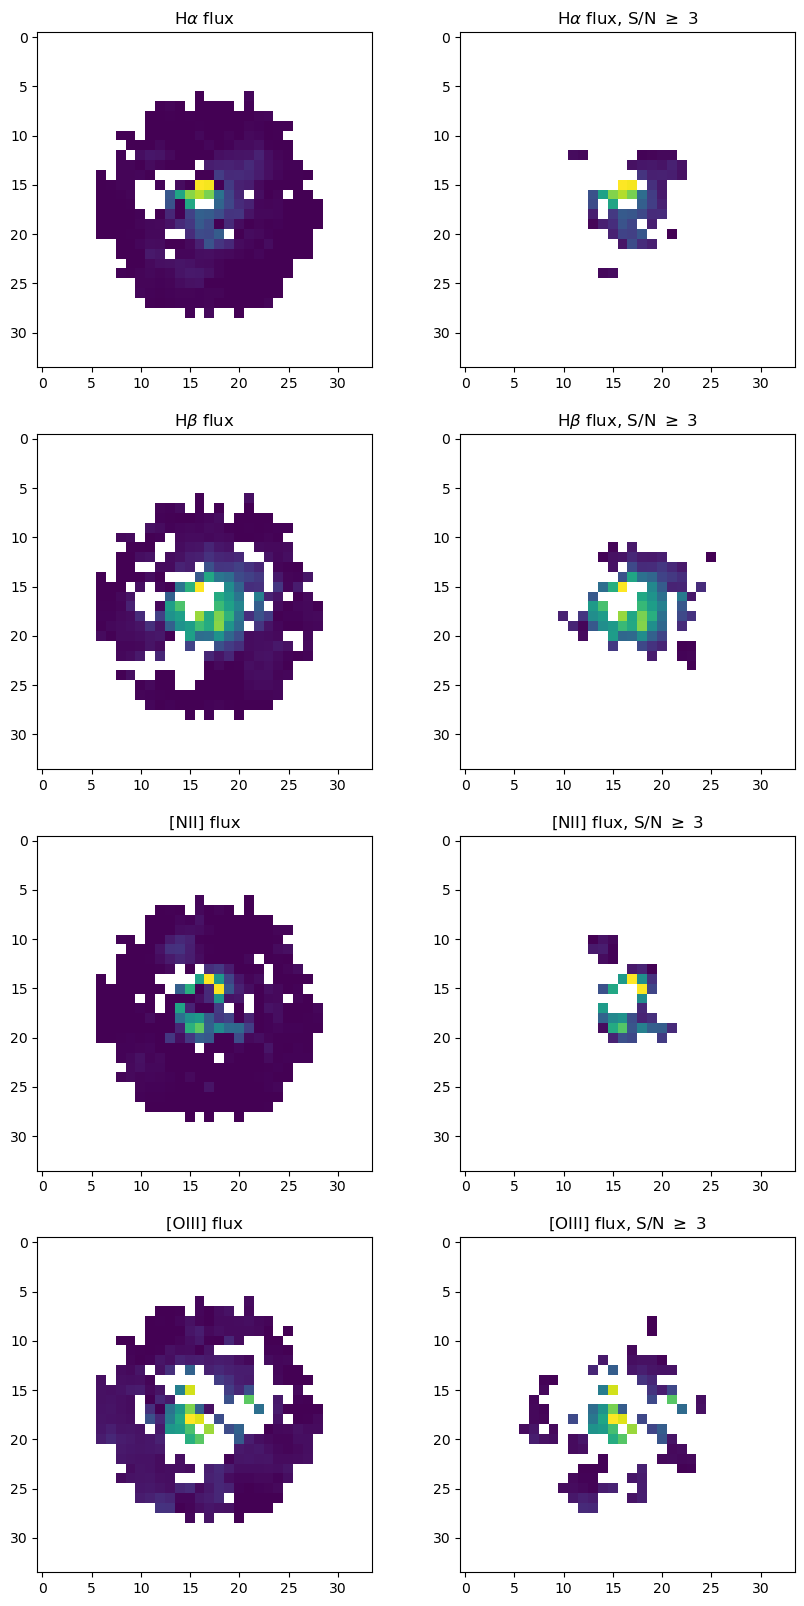

In [35]:
fig, ax = plt.subplots(4,2, figsize=(10,20))

ax[0,0].imshow(ma.array(maps['Ha_flux'], mask=maps['Ha_flux_mask']))
ax[0,1].imshow(ma.array(mHa_flux))

ax[1,0].imshow(ma.array(maps['Hb_flux'], mask=maps['Hb_flux_mask']))
ax[1,1].imshow(ma.array(mHb_flux))

ax[2,0].imshow(ma.array(maps['N2_flux'], mask=maps['N2_flux_mask']))
ax[2,1].imshow(ma.array(mN2_flux))

ax[3,0].imshow(ma.array(maps['O3_flux'], mask=maps['O3_flux_mask']))
ax[3,1].imshow(ma.array(mO3_flux))

ax[0,0].set_title(r'H$\alpha$ flux')
ax[0,1].set_title(r'H$\alpha$ flux, S/N $\geq$ 3')

ax[1,0].set_title(r'H$\beta$ flux')
ax[1,1].set_title(r'H$\beta$ flux, S/N $\geq$ 3')

ax[2,0].set_title(r'[NII] flux')
ax[2,1].set_title(r'[NII] flux, S/N $\geq$ 3')

ax[3,0].set_title(r'[OIII] flux')
ax[3,1].set_title(r'[OIII] flux, S/N $\geq$ 3')


## BPT classification with portsmouth fluxes

In [7]:
nsa_portsmouth = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/NSA_v1_0_1_vflag_Portsmouth.fits')
nsa_portsmouth[:5]

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS,u_r,g_r,NUV_r,index,imc,aimc,cd,conx1,u_r_KIAS,prmag,BPTclass,SFR,sSFR,HImass,vflag,u_r_err,g_r_err,NUV_r_err,ID,Flux_OII_3726,Flux_OII_3726_Err,AoN_OII_3726,Flux_OII_3728,Flux_OII_3728_Err,AoN_OII_3728,Flux_OIII_4363,Flux_OIII_4363_Err,AoN_OIII_4363,Flux_Hb_4861,Flux_Hb_4861_Err,AoN_Hb_4861,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,AoN_OIII_5006,Flux_NI_5197,Flux_NI_5197_Err,AoN_NI_5197,Flux_NI_5200,Flux_NI_5200_Err,AoN_NI_5200,Flux_OI_6300,Flux_OI_6300_Err,AoN_OI_6300,Flux_OI_6363,Flux_OI_6363_Err,AoN_OI_6363,Flux_NII_6547,Flux_NII_6547_Err,Flux_Ha_6562,Flux_Ha_6562_Err,AoN_Ha_6562,Flux_NII_6583,Flux_NII_6583_Err,AoN_NII_6583,Flux_SII_6716,Flux_SII_6716_Err,AoN_SII_6716,Flux_SII_6730,Flux_SII_6730_Err,AoN_SII_6730
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,bytes8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,bytes6,bytes27,bytes8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64,float32,float32,float32,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
J023211.77+001326.5,02h/p00/J023211.77+001326.5,38.04906209256324,0.22402153989646575,39438,22721,-1,-1,71327,-1,16.771198,0.054021582,sdss,0.07,109,4,23,301,1960.5631,83.361275,38979,0.054392263,1.3420134 .. 884.58374,16.215242 .. 0.0016165179,1,1.4780203 .. 964.8986,-13.908231 .. -21.045618,24.77356 .. 1073.0248,0.2271526 .. 0.04052578,-0.060923357 .. 0.029009609,1.4557369e-05 .. 1.222673e-15,0.0016189957 .. 1.23927,2.5023096e-06,0.06656253,0.024689334,22540354000.0,156.48558044433594,201.36697387695312,10 .. 11,0.016490662 .. 0.0,5489.7393 .. 0.0,0.21582535 .. -0.09177922,0.0076095443 .. 0.15974313,0.64479166 ..

In [13]:
nsa_dict = {}
for i in range(len(nsa_portsmouth)):
    nsa_dict[nsa_portsmouth['NSAID'][i]] = i

In [14]:
def BPT(Ha, Hb, N2, O3):
    '''
    1: SF
    2: comp
    3: AGN
    '''

    O3Hb = np.log10(O3/Hb)
    N2Ha = np.log10(N2/Ha)

    if N2Ha > 0.4:
        return 3

    if O3Hb < 0.61/(N2Ha - 0.05) + 1.3 and N2Ha < 0.01:
        return 1

    elif (0.61/(N2Ha - 0.05) + 1.3 < O3Hb and 0.61/(N2Ha - 0.47) + 1.19 > O3Hb) or (N2Ha > 0 and 0.61/(N2Ha - 0.47) + 1.19 > O3Hb):
        return 2

    else:
        return 3

def dust_corr(Ha, Hb, N2, O3, corr_law='CCM89'):
    
    rc= pn.RedCorr(law=corr_law)

    H_ratio = Ha/Hb

    rc.setCorr(H_ratio / 2.86, 6562, 4861)

    # in order Ha, Hb, NII, OIII
    wavelengths = np.array([6562, 4861, 6583, 5006])
    corr = rc.getCorrHb(wavelengths)

    Ha_corr = Ha * corr[0]
    Hb_corr = Hb * corr[1]
    N2_corr = N2 * corr[2]
    O3_corr = O3 * corr[3]

    return Ha_corr, Hb_corr, N2_corr, O3_corr

In [15]:
# add BPT flag to master table

master_table['BPT_class'] = 0.

for i in range(len(master_table)):

    # check if gal is elliptical
    if master_table['Mvir'][i] > 0 and master_table['sphd_M_star'][i] > 0:

        # find gal in portsmouth table
        nsaid = master_table[i]['nsa_nsaid']
        nsa_idx = nsa_dict[nsaid]

        # check that all necessary fluxes are > 0

        Ha = nsa_portsmouth['Flux_Ha_6562'][nsa_idx]
        Hb = nsa_portsmouth['Flux_Hb_4861'][nsa_idx]
        N2 = nsa_portsmouth['Flux_NII_6583'][nsa_idx]
        O3 = nsa_portsmouth['Flux_OIII_5006'][nsa_idx]

        if Ha > 0 and Hb > 0 and N2 > 0 and O3 > 0:


            # dust correct 
            Ha_corr, Hb_corr, N2_corr, O3_corr = dust_corr(Ha, Hb, N2, O3)
            
            
            master_table['BPT_class'][i] = BPT(Ha_corr,Hb_corr,N2_corr,O3_corr)

            

In [16]:
ellipticals = master_table[np.logical_and(master_table['Mvir'] > 0, master_table['sphd_M_star'] > 0)]

In [17]:
BPT_dict = {1.0: 'b',
            2.0: 'g',
            3.0:'r',
            0: 'k',}

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_16794/3424814182.py:27: RuntimeWarning: divide by zero encountered in scalar divide
  H_ratio = Ha/Hb
/Users/nityaravi/miniforge3/envs/RotationCurves/lib/python3.12/site-packages/pyneb/extinction/red_corr.py:252: RuntimeWarning: invalid value encountered in divide
  return np.squeeze(10. ** (0.4 * np.outer(X, self.E_BV).reshape(X.shape + self.E_BV.shape))) / rel_corr
/Users/nityaravi/miniforge3/envs/RotationCurves/lib/python3.12/site-packages/pyneb/extinction/red_corr.py:316: RuntimeWarning: divide by zero encountered in log10
  self.E_BV = 2.5 * np.log10(obs_over_theo) / (f1 - f2)
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_16794/4007361120.py:10: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(np.log10(N2/Ha),
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_16794/4007361120.py:11: RuntimeWarning: divide by zero encountered in log10
  np.log10(O3/Hb),
/var/folders/4q/zk1xkb454t7_ncsh

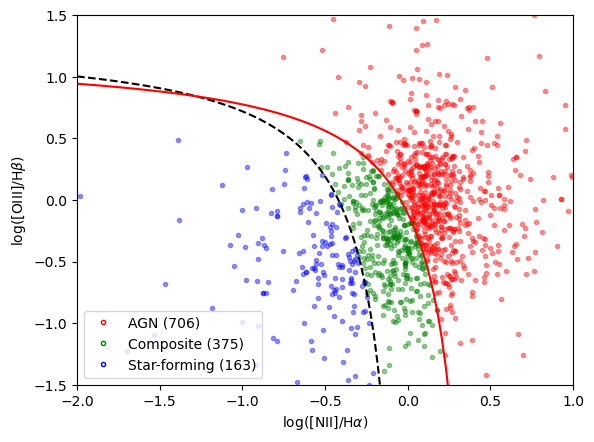

In [19]:
for i in range(len(ellipticals)):
    
    nsaid = ellipticals[i]['nsa_nsaid']
    nsa_idx = nsa_dict[nsaid]


    Ha, Hb, N2, O3 = dust_corr(nsa_portsmouth['Flux_Ha_6562'][nsa_idx], nsa_portsmouth['Flux_Hb_4861'][nsa_idx],
                               nsa_portsmouth['Flux_NII_6583'][nsa_idx], nsa_portsmouth['Flux_OIII_5006'][nsa_idx])

    plt.scatter(np.log10(N2/Ha),
                    np.log10(O3/Hb),
                    marker='.', color=BPT_dict[ellipticals[i]['BPT_class']],
                    alpha=0.4
               )

plt.xlim(-2,1)
plt.ylim(-1.5,1.5)

x = np.linspace(-2,0,100)
plt.plot(x,0.61/(x-0.05) + 1.3, color='k', linestyle='--')
x1 = np.linspace(-2,0.4,100)
plt.plot(x1,0.61/(x1 - 0.47) + 1.19, color='r')

plt.xlabel(r'log([NII]/H$\alpha$)')
plt.ylabel(r'log([OIII]/H$\beta$)')


legend_elements = [Line2D([0], [0], marker='o', color='w', label='AGN (' + str(len(ellipticals[ellipticals['BPT_class'] == 3])) + ')',
                          markeredgecolor='r', markersize=3),
                   Line2D([0], [0], marker='o', color='w', label='Composite (' + str(len(ellipticals[ellipticals['BPT_class'] == 2])) + ')',
                          markeredgecolor='g', markersize=3),
                   Line2D([0], [0], marker='o', color='w', label='Star-forming (' + str(len(ellipticals[ellipticals['BPT_class'] == 1])) + ')',
                          markeredgecolor='b', markersize=3)]

plt.legend(handles=legend_elements)
plt.savefig(plot_dir + 'ellipticals_BPT.png', bbox_inches='tight')

### mtot vs mstar colored by bpt

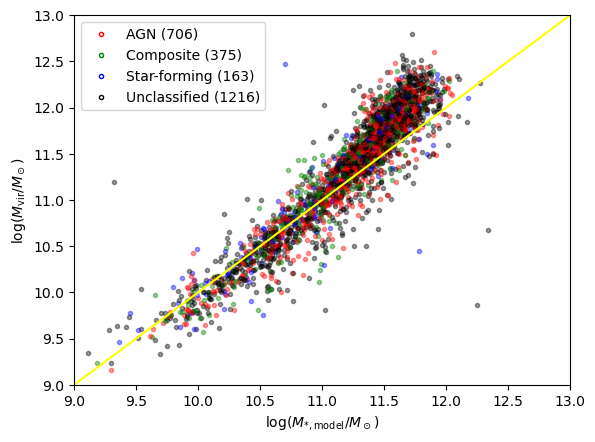

In [20]:
for i in range(len(ellipticals)):

    plt.scatter(ellipticals['sphd_M_star'][i], ellipticals['Mvir'][i], marker='.', color=BPT_dict[ellipticals[i]['BPT_class']],
                    alpha=0.4)


plt.xlabel(r'$\log(M_{*,\rm model}/M_\odot)$')
plt.ylabel(r'$\log(M_{\rm vir}/M_\odot)$')

plt.plot([9,13],[9,13], color='yellow')
plt.xlim(9,13)
plt.ylim(9,13)

legend_elements = [Line2D([0], [0], marker='o', color='w', label='AGN (' + str(len(ellipticals[ellipticals['BPT_class'] == 3])) + ')',
                          markeredgecolor='r', markersize=3),
                   Line2D([0], [0], marker='o', color='w', label='Composite (' + str(len(ellipticals[ellipticals['BPT_class'] == 2])) + ')',
                          markeredgecolor='g', markersize=3),
                   Line2D([0], [0], marker='o', color='w', label='Star-forming (' + str(len(ellipticals[ellipticals['BPT_class'] == 1])) + ')',
                          markeredgecolor='b', markersize=3),
                  Line2D([0], [0], marker='o', color='w', label='Unclassified (' + str(len(ellipticals[ellipticals['BPT_class'] == 0])) + ')',
                          markeredgecolor='k', markersize=3)]

plt.legend(handles=legend_elements)
plt.savefig(plot_dir + 'Mtot_Mstar_BPT_all.png', bbox_inches='tight')

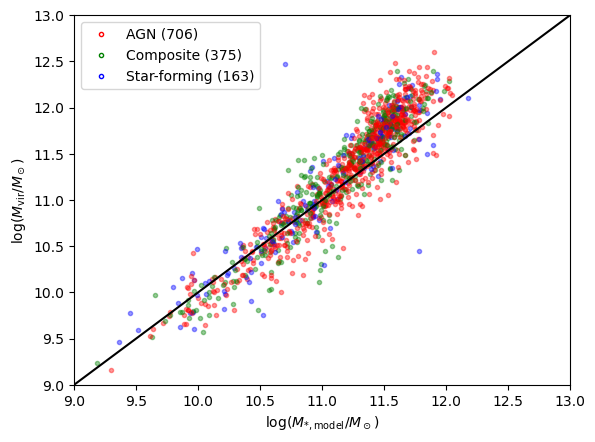

In [21]:
for i in range(len(ellipticals)):

    if ellipticals['BPT_class'][i] != 0:

        plt.scatter(ellipticals['sphd_M_star'][i], ellipticals['Mvir'][i], marker='.', color=BPT_dict[ellipticals[i]['BPT_class']],
                    alpha=0.4)


plt.xlabel(r'$\log(M_{*,\rm model}/M_\odot)$')
plt.ylabel(r'$\log(M_{\rm vir}/M_\odot)$')

plt.plot([9,13],[9,13], color='k')
plt.xlim(9,13)
plt.ylim(9,13)

legend_elements = [Line2D([0], [0], marker='o', color='w', label='AGN (' + str(len(ellipticals[ellipticals['BPT_class'] == 3])) + ')',
                          markeredgecolor='r', markersize=3),
                   Line2D([0], [0], marker='o', color='w', label='Composite (' + str(len(ellipticals[ellipticals['BPT_class'] == 2])) + ')',
                          markeredgecolor='g', markersize=3),
                   Line2D([0], [0], marker='o', color='w', label='Star-forming (' + str(len(ellipticals[ellipticals['BPT_class'] == 1])) + ')',
                          markeredgecolor='b', markersize=3)]

plt.legend(handles=legend_elements)
plt.savefig(plot_dir + 'Mtot_Mstar_BPT.png', bbox_inches='tight')

In [22]:
master_table.write(master_table_fn, format='fits', overwrite=True)